In [2]:
# Create an environment for this.

# Indoor Temperature Prediction using Netatmo Weather Data

# This notebook trains a simple neural network to predict indoor temperature from Netatmo weather station measurements.

# Features used:
# - Outdoor temperature
# - Outdoor humidity
# - Time-of-day and seasonal time features
# - Previous indoor temperature measurements (lag features)

# The data is split chronologically into training, validation, and test periods to avoid information leakage from future observations. A small feed-forward neural network is trained and evaluated, and the predicted indoor temperatures are compared against the measured values on the test period.

# Goal:
# - Explore the predictability of indoor temperature
# - Capture the thermal inertia of the house using historical indoor measurements
# - Establish a baseline model for future time-series models such as LSTMs or other sequence-based neural networks

In [3]:
## Imports

from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

plt.style.use("default")
sns.set_theme()

%matplotlib inline

In [4]:
## Find all Weather.csv files

DATA_ROOT = Path("../data/csv")

weather_files = sorted(DATA_ROOT.glob("*/Weather.csv"))

print(f"Found {len(weather_files)} weather files:\n")

for i, f in enumerate(weather_files):
    print(f"{i}: {f.parent.name}")

Found 3 weather files:

0: Huis_19_06_2026_30min
1: Huis_19_06_2026_all
2: Huis_may_2025


In [5]:
## Loader

def load_weather_file(path):
    """
    Load Netatmo-style Weather.csv export.
    """

    df = pd.read_csv(
        path,
        skiprows=5,
        sep=",",
        engine="python"
    )

    df.columns = [str(c).strip() for c in df.columns]

    rename_map = {
        "Timezone : Europe/Amsterdam": "datetime",
    }

    df = df.rename(columns=rename_map)

    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"])

    return df

In [12]:
## Load data

path = weather_files[2]

df = load_weather_file(path)

print(path.parent.name)

df.head()

Huis_may_2025


,Timestamp,datetime,Temperature °C,Humidity %,CO2 ppm,Noise dB,Pressure Pa,Unnamed: 7,Temperature °C.1,Humidity %.1,Unnamed: 10
0,1745964150,2025-04-30 00:02:30,22.3,52,1168,32,1022.7,NaN,14.1,80.0,NaN
1,1745964450,2025-04-30 00:07:30,22.3,52,1168,32,1022.7,NaN,14.2,80.0,NaN
2,1745964750,2025-04-30 00:12:30,22.2,52,1168,32,1022.7,NaN,14.1,80.0,NaN
3,1745965050,2025-04-30 00:17:30,22.3,52,1141,33,1022.7,NaN,14.1,80.0,NaN
4,1745965350,2025-04-30 00:22:30,22.2,52,1141,34,1022.7,NaN,14.1,81.0,NaN


In [14]:
## Inspect columns

print(df.columns.tolist())

['Timestamp', 'datetime', 'Temperature °C', 'Humidity %', 'CO2 ppm', 'Noise dB', 'Pressure Pa', 'Unnamed: 7', 'Temperature °C.1', 'Humidity %.1', 'Unnamed: 10']


In [15]:
## Rename columns

df = df.rename(
    columns={
        "Temperature °C": "temp_in",
        "Humidity %": "hum_in",
        "Temperature °C.1": "temp_out",
        "Humidity %.1": "hum_out",
    }
)

df = df.sort_values("datetime")

df.head()

,Timestamp,datetime,temp_in,hum_in,CO2 ppm,Noise dB,Pressure Pa,Unnamed: 7,temp_out,hum_out,Unnamed: 10
0,1745964150,2025-04-30 00:02:30,22.3,52,1168,32,1022.7,NaN,14.1,80.0,NaN
1,1745964450,2025-04-30 00:07:30,22.3,52,1168,32,1022.7,NaN,14.2,80.0,NaN
2,1745964750,2025-04-30 00:12:30,22.2,52,1168,32,1022.7,NaN,14.1,80.0,NaN
3,1745965050,2025-04-30 00:17:30,22.3,52,1141,33,1022.7,NaN,14.1,80.0,NaN
4,1745965350,2025-04-30 00:22:30,22.2,52,1141,34,1022.7,NaN,14.1,81.0,NaN


In [16]:
## Create time features

df["hour"] = df["datetime"].dt.hour
df["minute"] = df["datetime"].dt.minute

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dayofyear"] = df["datetime"].dt.dayofyear

df["day_sin"] = np.sin(
    2 * np.pi * df["dayofyear"] / 365.25
)

df["day_cos"] = np.cos(
    2 * np.pi * df["dayofyear"] / 365.25
)

In [17]:
## Create lag features

N_LAGS = 12
# 12 x 5 min = 1 hour history

for lag in range(1, N_LAGS + 1):
    df[f"temp_in_lag_{lag}"] = df["temp_in"].shift(lag)

df = df.dropna()

print(df.shape)

(0, 30)


In [18]:
## Build feature matrix

feature_columns = [
    "temp_out",
    "hum_out",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
]

feature_columns += [
    f"temp_in_lag_{lag}"
    for lag in range(1, N_LAGS + 1)
]

target_column = "temp_in"

X = df[feature_columns]
y = df[target_column]

In [19]:
## Train / validation / test split

n = len(df)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

print("Train:", len(X_train))
print("Val:  ", len(X_val))
print("Test: ", len(X_test))

Train: 0
Val:   0
Test:  0


In [12]:
## Scale features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

ValueError: Found array with 0 sample(s) (shape=(0, 18)) while a minimum of 1 is required by StandardScaler.

In [13]:
## Neural network

model = Sequential([
    Dense(64, activation="relu",
          input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

NameError: name 'X_train_scaled' is not defined

In [14]:
## Train model

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

NameError: name 'EarlyStopping' is not defined

NameError: name 'history' is not defined

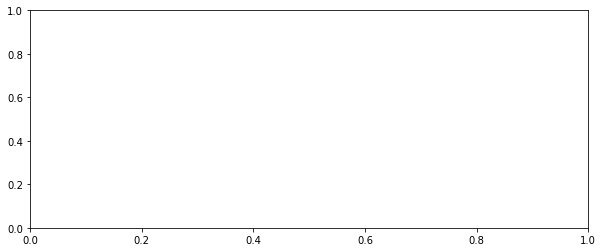

In [15]:
## Training history

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(history.history["loss"], label="train")
ax.plot(history.history["val_loss"], label="validation")

ax.set_ylabel("MSE")
ax.set_xlabel("Epoch")
ax.legend()

plt.show()

In [16]:
## Predict test period

y_pred = model.predict(X_test_scaled).flatten()

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE  = {mae:.3f} °C")
print(f"RMSE = {rmse:.3f} °C")

NameError: name 'model' is not defined

ValueError: Multi-dimensional indexing (e.g. `obj[:, None]`) is no longer supported. Convert to a numpy array before indexing instead.

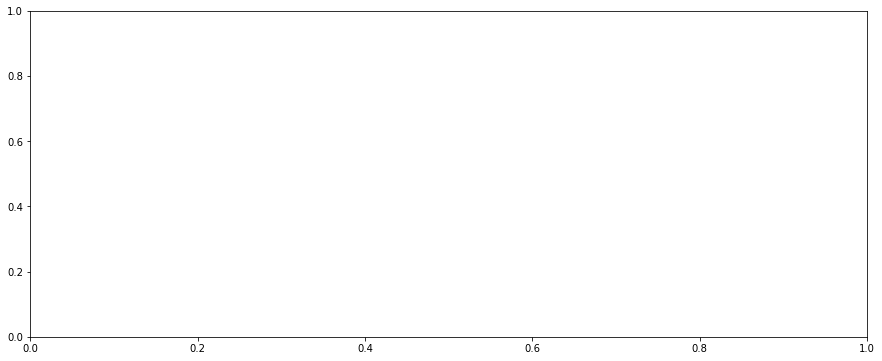

In [17]:
## Plot prediction on test period

test_time = df.iloc[val_end:]["datetime"]

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    test_time,
    y_test,
    label="Measured indoor temperature",
    linewidth=2
)

ax.plot(
    test_time,
    y_pred,
    label="Predicted indoor temperature",
    linewidth=2
)

ax.set_title("Indoor temperature prediction")
ax.set_ylabel("Temperature (°C)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
## Zoom into first week of test data

N = 7 * 24 * 12
# 7 days at 5-minute intervals

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    test_time.iloc[:N],
    y_test.iloc[:N],
    label="Measured"
)

ax.plot(
    test_time.iloc[:N],
    y_pred[:N],
    label="Predicted"
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()